In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
# eqCLR_pmnist
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb

import torchvision.transforms as transforms
from torchvision.models import resnet18

import numpy as np
import time
import pickle

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from medmnist import PathMNIST

from eqCLR.eq_resnet import EqResNet18, Mixed_EqResnet18, EqResNet18_SO2, EqResNet18_v2, EqResNet, eq_resnet, EqResNet18_hue
from eqCLR.test_resnet import Wide_ResNet
from evaluation import model_eval, eval_knn_single, dataset_to_X_y, lin_eval_rep
from escnn import gspaces

In [3]:
BATCH_SIZE = 512
N_EPOCHS = 100 # 1000
N_CPU_WORKERS = 16
BASE_LR = 0.06         # 0.03
WEIGHT_DECAY = 5e-4    # important
MOMENTUM = 0.9
PROJECTOR_HIDDEN_SIZE = 1024
PROJECTOR_OUTPUT_SIZE = 128
CROP_LOW_SCALE = 0.2
GRAYSCALE_PROB = 0.1   # important
PRINT_EVERY_EPOCHS = 1
EVAL_DURING_TRAIN = True
ITER_SAVE_EMBED = 50
IMG_RESIZE = 33  # if None, use original size 28x28
MAXPOOL = 'max'  # 'avg' or 'max' or None
N_grid = 16  # for steerable CNN
IRREPS_L = 12  # for steerable CNN

MODEL_FILENAME = f"{np.random.randint(10000):04}-path_mnist-eqCLR_hsv_hue_eq2"

print(f"Model filename: {MODEL_FILENAME}")

Model filename: 0779-path_mnist-eqCLR_hsv_hue_eq2


In [4]:
###################### DATA LOADER #########################
class RGBToHSV:
    """Custom transform: convert RGB tensor [C,H,W] in [0,1] to HSV [C,H,W]"""
    def __call__(self, img_tensor):
        # img_tensor: [C,H,W] in [0,1]
        img_np = img_tensor.permute(1, 2, 0).numpy()  # [H,W,C]
        hsv_np = rgb_to_hsv(img_np)                    # [H,W,C], hue in [0,1]
        hsv_tensor = torch.tensor(hsv_np).permute(2, 0, 1)  # back to [C,H,W]
        return hsv_tensor
    
if IMG_RESIZE is not None:
    transform = transforms.Compose([
        transforms.Resize((IMG_RESIZE, IMG_RESIZE)),
        transforms.ToTensor(),
        RGBToHSV()
    ])
else:
    transform = transforms.ToTensor()

pmnist_train_hsv = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transform)
pmnist_test_hsv= PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)
print("Data loaded.")

if IMG_RESIZE is None:
    IMG_RESIZE = pmnist_train_hsv[0][0].shape[1]  # get image size from dataset
print(f"Image size (resized): {IMG_RESIZE}")

# additional rotation
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

transforms_ssl_hsv = transforms.Compose(
    [
        transforms.Resize((IMG_RESIZE, IMG_RESIZE)),
        transforms.RandomResizedCrop(size=IMG_RESIZE, scale=(CROP_LOW_SCALE, 1)),
        # RandomRightAngleRotation(), # additional rotation
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply(
            [transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8
        ),
        transforms.RandomGrayscale(p=GRAYSCALE_PROB),
        transforms.ToTensor(), # NB: runtime faster when this line is last
        RGBToHSV()
    ]
)

class PairedTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return (self.transform(x), self.transform(x))


paired_ssl_transforms_hsv = PairedTransform(transforms_ssl_hsv)

pmnist_train_ssl_hsv = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=paired_ssl_transforms_hsv)

pmnist_loader_ssl_hsv = DataLoader(
    pmnist_train_ssl_hsv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=N_CPU_WORKERS,
    pin_memory=True,
)

Data loaded.
Image size (resized): 33


In [5]:
if IMG_RESIZE is not None:
    transform = transforms.Compose([
        transforms.Resize((IMG_RESIZE, IMG_RESIZE)),
        transforms.ToTensor(),
    ])
else:
    transform = transforms.ToTensor()

pmnist_train_rgb = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=transform)
pmnist_test_rgb= PathMNIST(split='test', download=False, size=28, root='data/pathmnist/', transform=transform)
print("Data loaded.")

if IMG_RESIZE is None:
    IMG_RESIZE = pmnist_train_rgb[0][0].shape[1]  # get image size from dataset
print(f"Image size (resized): {IMG_RESIZE}")

# additional rotation
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

transforms_ssl_rgb = transforms.Compose(
    [
        transforms.Resize((IMG_RESIZE, IMG_RESIZE)),
        transforms.RandomResizedCrop(size=IMG_RESIZE, scale=(CROP_LOW_SCALE, 1)),
        # RandomRightAngleRotation(), # additional rotation
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply(
            [transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8
        ),
        transforms.RandomGrayscale(p=GRAYSCALE_PROB),
        transforms.ToTensor(), # NB: runtime faster when this line is last
    ]
)

class PairedTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return (self.transform(x), self.transform(x))


paired_ssl_transforms_rgb = PairedTransform(transforms_ssl_rgb)

pmnist_train_ssl_rgb = PathMNIST(split='train', download=False, size=28, root='data/pathmnist/', transform=paired_ssl_transforms_rgb)

pmnist_loader_ssl_rgb = DataLoader(
    pmnist_train_ssl_rgb,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=N_CPU_WORKERS,
    pin_memory=True,
)

Data loaded.
Image size (resized): 33


In [6]:
###################### NETWORK ARCHITECTURE #########################

def infoNCE(features, temperature=0.5):
    x = F.normalize(features)
    cos_xx = x @ x.T / temperature
    cos_xx.fill_diagonal_(float("-inf"))
    
    batch_size = cos_xx.size(0) // 2
    targets = torch.arange(batch_size * 2, dtype=int, device=cos_xx.device)
    targets[:batch_size] += batch_size
    targets[batch_size:] -= batch_size

    return F.cross_entropy(cos_xx, targets)

# model = Mixed_EqResnet18(resnet18, N=8, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE)
#model = Wide_ResNet(10, 4, 0.1, initial_stride=1, N=4, f=False, r=0, num_classes=128)
model_rgb = EqResNet18(N=4, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')
# model = EqResNet18_SO2(N=-1, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE)
# model = EqResNet18_v2(N=-1, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, N_grid=N_grid, irreps_L=IRREPS_L, S=1)
# model = EqResNet(N=4, layers=[3,4,6,3], block='basic', keep_dim=True)
model_hsv = EqResNet18_hue(N=4, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param', gpool_mode='max')

optimizer = SGD(
    model_hsv.parameters(),
    lr=BASE_LR * BATCH_SIZE / 256,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

{'irrep_0': C4|[irrep_0]:1, 'irrep_1': C4|[irrep_1]:2, 'irrep_2': C4|[irrep_2]:1}
S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256
S = 2.0
{'irrep_0': C1|[irrep_0]:1}
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [42]:
model_rgb_tr = EqResNet18(N=4, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')


S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [43]:
device = "cuda"
model_rgb_tr.to(device)
model_rgb_tr.load_state_dict(torch.load(f'results/model_weights/1010-path_mnist-eqCLR_resnet18_N4_keepdim_params_resize33_weights.pt', weights_only=True))
print('Weights loaded.')
model_rgb_tr.eval()


Weights loaded.


EqResNet18(
  (conv1): R2Conv([C4_on_R2[(None, 4)]: {irrep_0 (x3)}(3)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=7, stride=2, padding=3)
  (bn1): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=False, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
  (maxpool): PointwiseMaxPool2D()
  (layer1): SequentialModule(
    (0): EqBasicBlock(
      (conv1): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padding=1, bias=False)
      (bn1): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=False, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
      (conv2): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padding=1, bias=False)
      

In [48]:
model_hsv_tr = EqResNet18_hue(N=4, maxpool=MAXPOOL, projector_hidden_size=PROJECTOR_HIDDEN_SIZE, n_classes=PROJECTOR_OUTPUT_SIZE, adjust_channels='keep_param')

S = 2.0
Make layer
Make layer
Make layer
Make layer
Final feature dimension: 256


In [49]:
device = "cuda"
model_hsv_tr.to(device)
model_hsv_tr.load_state_dict(torch.load(f'results/model_weights/2857-path_mnist-eqCLR_hsv_hue_eq2_weights.pt', weights_only=True))
print('Weights loaded.')
model_hsv_tr.eval()

Weights loaded.


EqResNet18_hue(
  (encoder): HSVHuePhaseEncoder()
  (conv1): R2Conv([C4_on_R2[hueOnR2(H=4)]: {irrep_1 (x1), irrep_0 (x2)}(4)], [C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], kernel_size=7, stride=2, padding=3)
  (bn1): InnerBatchNorm([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=False, type=[C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)])
  (maxpool): PointwiseMaxPool2D()
  (layer1): SequentialModule(
    (0): EqBasicBlock(
      (conv1): R2Conv([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], [C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], kernel_size=3, stride=1, padding=1, bias=False)
      (bn1): InnerBatchNorm([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=False, type=[C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)])
      (conv2): R2Conv([C4_on_R2[hueOnR2(H=4)]: {regular (x32)}(128)], [C4_on_R2[hueOnR2(H=

In [7]:
model_rgb.to('cuda')
model_rgb.eval()

with torch.no_grad():
    X_train_rgb, y_train_rgb, Z_train_rgb = dataset_to_X_y(pmnist_train_rgb, model_rgb)
    X_test_rgb, y_test_rgb, Z_test_rgb = dataset_to_X_y(pmnist_test_rgb, model_rgb)
    knn_acc_rgb = eval_knn_single(X_train_rgb, y_train_rgb, X_test_rgb, y_test_rgb)
print(f"RGB kNN accuracy: {knn_acc_rgb:.4f}")

RGB kNN accuracy: 0.5625


In [8]:
print(Z_test_rgb.mean(), Z_test_rgb.std())
print(X_test_rgb.mean(), X_test_rgb.std())

-0.008895473 0.1564204
0.48643556 0.46797526


In [9]:
print(Z_test_rgb.mean(), Z_test_rgb.std())
print(X_test_rgb.mean(), X_test_rgb.std())

-0.008895473 0.1564204
0.48643556 0.46797526


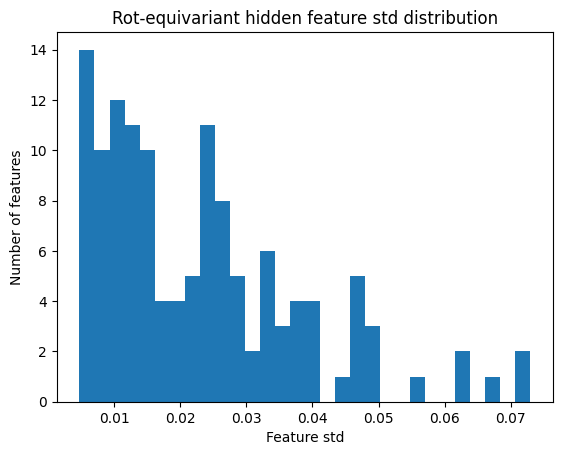

In [10]:
import torch
import matplotlib.pyplot as plt

std_per_dim_rgb = Z_test_rgb.std(axis=0)
plt.hist(std_per_dim_rgb, bins=30)
plt.xlabel("Feature std")
plt.ylabel("Number of features")
plt.title("Rot-equivariant hidden feature std distribution")
plt.show()

In [11]:
model_hsv.to('cuda')
model_hsv.eval()

with torch.no_grad():
    X_train_hsv, y_train_hsv, Z_train_hsv = dataset_to_X_y(pmnist_train_hsv, model_hsv)
    X_test_hsv, y_test_hsv, Z_test_hsv = dataset_to_X_y(pmnist_test_hsv, model_hsv)
    knn_acc_hsv = eval_knn_single(X_train_hsv, y_train_hsv, X_test_hsv, y_test_hsv)
print(f"HSV kNN accuracy: {knn_acc_hsv:.4f}")

HSV kNN accuracy: 0.4951


In [12]:
print(Z_test_hsv.mean(), Z_test_hsv.std())
print(X_test_hsv.mean(), X_test_hsv.std())

0.02862072 0.18016388
0.59004885 0.4744651


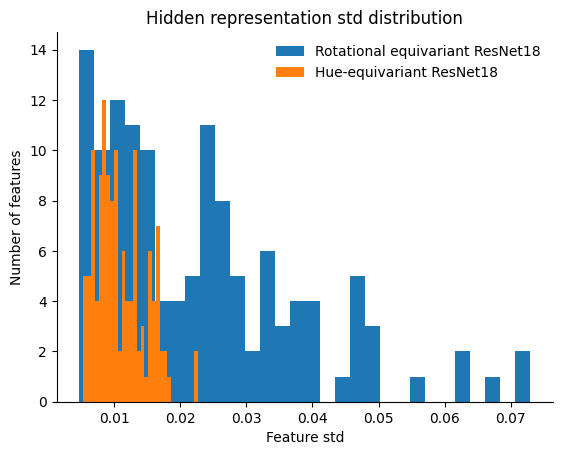

In [20]:
import torch
import matplotlib.pyplot as plt

std_per_dim = Z_test_hsv.std(axis=0)
plt.hist(std_per_dim_rgb, bins=30, label='Rotational equivariant ResNet18')
plt.hist(std_per_dim, bins=30, label='Hue-equivariant ResNet18')

plt.xlabel("Feature std")
plt.ylabel("Number of features")
plt.title("Hidden representation std distribution")
plt.legend(frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
# rot rgb trained
with torch.no_grad():
    X_train_rgb_tr, y_train_rgb_tr, Z_train_rgb_tr = dataset_to_X_y(pmnist_train_rgb, model_rgb_tr)
    X_test_rgb_tr, y_test_rgb_tr, Z_test_rgb_tr = dataset_to_X_y(pmnist_test_rgb, model_rgb_tr)
    knn_acc_rgb_tr = eval_knn_single(X_train_rgb_tr, y_train_rgb_tr, X_test_rgb_tr, y_test_rgb_tr)
print(f"RGB kNN accuracy: {knn_acc_rgb_tr:.4f}")

RGB kNN accuracy: 0.8889


In [60]:
print(Z_test_rgb_tr.mean(), Z_test_rgb_tr.std())
print(X_test_rgb_tr.mean(), X_test_rgb_tr.std())

0.0008554816 0.028254377
0.067130044 0.141108


In [50]:
# hue hsv trained
with torch.no_grad():
    X_train_hsv_tr, y_train_hsv_tr, Z_train_hsv_tr = dataset_to_X_y(pmnist_train_hsv, model_hsv_tr)
    X_test_hsv_tr, y_test_hsv_tr, Z_test_hsv_tr = dataset_to_X_y(pmnist_test_hsv, model_hsv_tr)
    knn_acc_hsv_tr = eval_knn_single(X_train_hsv_tr, y_train_hsv_tr, X_test_hsv_tr, y_test_hsv_tr)
print(f"HSV kNN accuracy: {knn_acc_hsv_tr:.4f}")

HSV kNN accuracy: 0.8304


In [62]:
print(Z_test_hsv_tr.mean(), Z_test_hsv_tr.std())
print(X_test_hsv_tr.mean(), X_test_hsv_tr.std())

0.00029382476 0.032832075
0.08914279 0.1575469


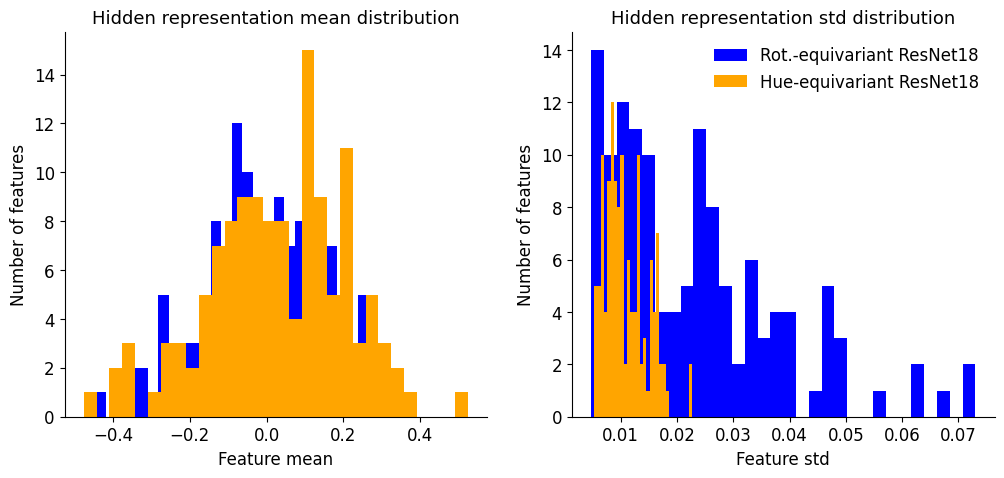

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fontsize = 12

mean_per_dim_hsv = Z_test_hsv.mean(axis=0)
mean_per_dim_rgb = Z_test_rgb.mean(axis=0)

ax[0].hist(mean_per_dim_rgb, bins=30, label='Rot.-equivariant ResNet', color='blue')
ax[0].hist(mean_per_dim_hsv, bins=30, label='Hue-equivariant ResNet', color='orange')

ax[0].set_xlabel("Feature mean", fontsize=fontsize)
ax[0].set_ylabel("Number of features", fontsize=fontsize)
ax[0].set_title("Hidden representation mean distribution", fontsize=fontsize+1)
# plt.legend(frameon=False, loc='upper left')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


ax[1].hist(std_per_dim_rgb, bins=30, label='Rot.-equivariant ResNet18', color='blue')
ax[1].hist(std_per_dim, bins=30, label='Hue-equivariant ResNet18', color='orange')
ax[1].set_xlabel("Feature std", fontsize=fontsize)
ax[1].set_ylabel("Number of features", fontsize=fontsize)
ax[1].set_title("Hidden representation std distribution", fontsize=fontsize+1)
ax[1].legend(frameon=False, fontsize=fontsize, loc='upper right')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

for a in ax:
    a.tick_params(axis='both', which='major', labelsize=fontsize)
plt.show()

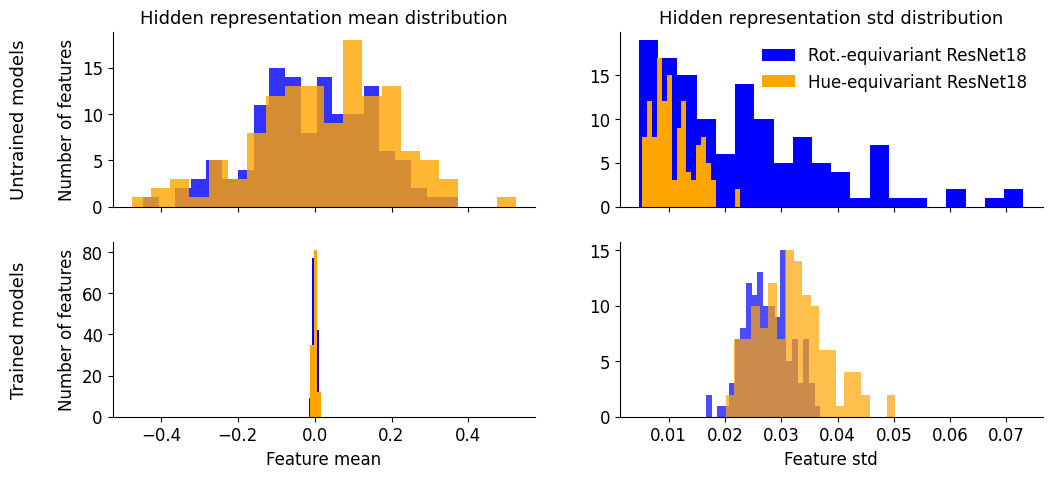

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5), sharex='col')
fontsize = 12

mean_per_dim_hsv = Z_test_hsv.mean(axis=0)
mean_per_dim_rgb = Z_test_rgb.mean(axis=0)

# trained
mean_per_dim_rgb_tr = Z_test_rgb_tr.mean(axis=0)
std_per_dim_rgb_tr = Z_test_rgb_tr.std(axis=0)
mean_per_dim_hsv_tr = Z_test_hsv_tr.mean(axis=0)
std_per_dim_hsv_tr = Z_test_hsv_tr.std(axis=0)

ax[0, 0].hist(mean_per_dim_rgb,alpha=0.8, bins=20, label='Rot.-equivariant ResNet', color='blue')
ax[0, 0].hist(mean_per_dim_hsv,alpha=0.8, bins=20, label='Hue-equivariant ResNet', color='orange')

ax[1, 0].hist(mean_per_dim_rgb_tr, bins=3, label='Rot.-equivariant ResNet (trained)', color='blue')
ax[1, 0].hist(mean_per_dim_hsv_tr, bins=3, label='Hue-equivariant ResNet (trained)', color='orange')

ax[1, 0].set_xlabel("Feature mean", fontsize=fontsize)
ax[0, 0].set_ylabel("Number of features", fontsize=fontsize)
ax[0, 0].set_title("Hidden representation mean distribution", fontsize=fontsize+1)

ax[0, 1].hist(std_per_dim_rgb, bins=20, label='Rot.-equivariant ResNet18', color='blue')
ax[0, 1].hist(std_per_dim, bins=20, label='Hue-equivariant ResNet18', color='orange')
ax[1, 1].hist(std_per_dim_rgb_tr,alpha=0.7, bins=20, label='Rot.-equivariant ResNet18 (trained)', color='blue')
ax[1, 1].hist(std_per_dim_hsv_tr,alpha=0.7, bins=20, label='Hue-equivariant ResNet18 (trained)', color='orange')

ax[1, 1].set_xlabel("Feature std", fontsize=fontsize)
ax[1, 0].set_ylabel("Number of features", fontsize=fontsize)
ax[0, 1].set_title("Hidden representation std distribution", fontsize=fontsize+1)
ax[0, 1].legend(frameon=False, fontsize=fontsize, loc='upper right')

ax[0, 0].text(
        -0.2, 0.5, 'Untrained models',   # position (left of plot)
        transform=ax[0, 0].transAxes,
        fontsize=13,
        va='center',
        ha='right',
        rotation=90
    )

ax[1, 0].text(
        -0.2, 0.5, 'Trained models',   # position (left of plot)
        transform=ax[1, 0].transAxes,
        fontsize=13,
        va='center',
        ha='right',
        rotation=90
    )

for a in ax.flatten():
    a.tick_params(axis='both', which='major', labelsize=fontsize)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.show()

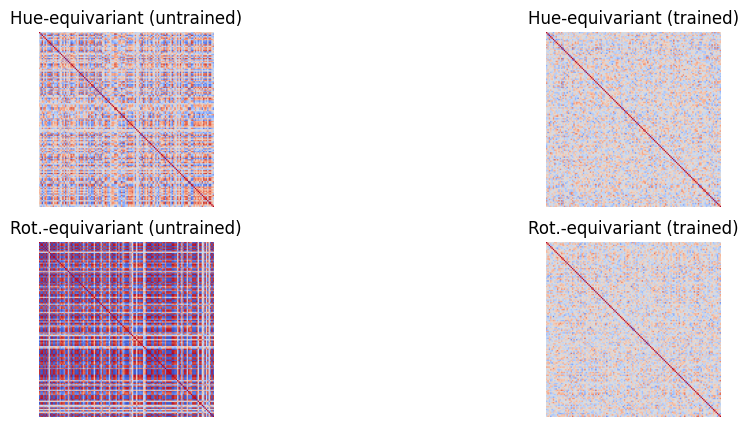

In [71]:
fig, ax = plt.subplots(2, 2, figsize=(12, 5))

corr_hsv = np.corrcoef(Z_test_hsv.T)  
corr_rgb = np.corrcoef(Z_test_rgb.T)  
corr_hsv_tr = np.corrcoef(Z_test_hsv_tr.T)  
corr_rgb_tr = np.corrcoef(Z_test_rgb_tr.T)  

corrs = {
    'Hue-equivariant (untrained)': corr_hsv,
    'Hue-equivariant (trained)': corr_hsv_tr,
    'Rot.-equivariant (untrained)': corr_rgb,
    'Rot.-equivariant (trained)': corr_rgb_tr
}

for i, (title, corr) in enumerate(corrs.items()):
    ax[i//2, i%2].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax[i//2, i%2].set_title(title)
    ax[i//2, i%2].axis('off')


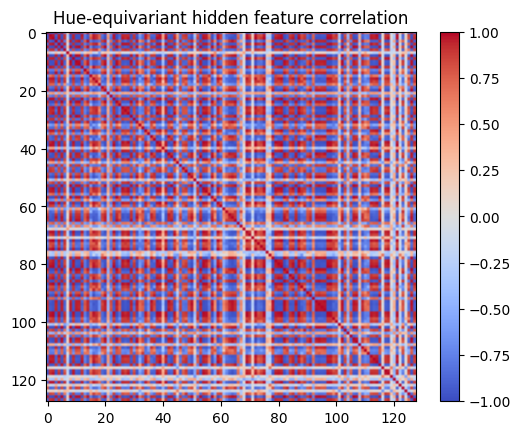

In [ ]:
corr = np.corrcoef(Z_test_rgb.T)  # shape (128, 128)

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Rotation-equivariant hidden feature correlation")
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
fontsize = 12

mean_per_dim_hsv = Z_test_hsv.mean(axis=0)
mean_per_dim_rgb = Z_test_rgb.mean(axis=0)

ax[0, 0].hist(mean_per_dim_rgb, bins=30, label='Rot.-equivariant ResNet', color='blue')
ax[0, 0].hist(mean_per_dim_hsv, bins=30, label='Hue-equivariant ResNet', color='orange')

ax[1, 0].hist(mean_per_dim_rgb_tr, bins=20, label='Rot.-equivariant ResNet (trained)', color='blue')
ax[1, 0].hist(mean_per_dim_hsv_tr, bins=20, label='Hue-equivariant ResNet (trained)', color='orange')

for i in range(2):
    ax[i, 0].set_xlabel("Feature mean", fontsize=fontsize)
    ax[i, 0].set_ylabel("Number of features", fontsize=fontsize)
    ax[i, 0].set_title("Hidden representation mean distribution", fontsize=fontsize+1)
    # pi, lt.legend(frameon=False, loc='upper left')
    ax[i, 0].spines['top'].set_visible(False)
    ax[i, 0].spines['right'].set_visible(False)


ax[0, 1].hist(std_per_dim_rgb, bins=30, label='Rot.-equivariant ResNet18', color='blue')
ax[0, 1].hist(std_per_dim, bins=30, label='Hue-equivariant ResNet18', color='orange')
ax[1, 1].hist(std_per_dim_rgb_tr, bins=30, label='Rot.-equivariant ResNet18 (trained)', color='blue')
ax[1, 1].hist(std_per_dim_hsv_tr, bins=30, label='Hue-equivariant ResNet18 (trained)', color='orange')

for i in range(2):
    ax[i, 1].set_xlabel("Feature std", fontsize=fontsize)
    ax[i, 1].set_ylabel("Number of features", fontsize=fontsize)
    ax[i, 1].set_title("Hidden representation std distribution", fontsize=fontsize+1)
    ax[i, 1].legend(frameon=False, fontsize=fontsize, loc='upper right')
    ax[i, 1].spines['top'].set_visible(False)
    ax[i, 1].spines['right'].set_visible(False)

for a in ax.flatten():
    a.tick_params(axis='both', which='major', labelsize=fontsize)
plt.show()

# Eval different models

In [38]:
# default resnet18
with open('results/model_eval/5561-resnet18_resize_33_default_eval.pkl', 'rb') as f:
    eval_resnet18 = pickle.load(f)

with open('results/model_details/5561-resnet18_resize_33_default_details.pkl', 'rb') as f:
    details_resnet18 = pickle.load(f)

# default resnet18 hsv input
with open('results/model_eval/6804-resnet18_hsv_eval.pkl', 'rb') as f:
    eval_resnet18_hsv = pickle.load(f)

with open('results/model_details/6804-resnet18_hsv_details.pkl', 'rb') as f:
    details_resnet18_hsv = pickle.load(f)

# eqResnet constant param N=4 rotation (rgb input)
with open('results/model_eval/1010-path_mnist-eqCLR_resnet18_N4_keepdim_params_resize33_eval.pkl', 'rb') as f:
    eval_eqresnet_rot = pickle.load(f)

with open('results/model_details/1010-path_mnist-eqCLR_resnet18_N4_keepdim_params_resize33_details.pkl', 'rb') as f:
    details_eqresnet_rot = pickle.load(f)

# eqResnet constant param N=4 rotation (hsv input)
with open('results/model_eval/6320-path_mnist-eqCLR_hsv_rot_eq_eval.pkl', 'rb') as f:
    eval_eqresnet_rot_hsv = pickle.load(f)

with open('results/model_details/6320-path_mnist-eqCLR_hsv_rot_eq_details.pkl', 'rb') as f:
    details_eqresnet_rot_hsv = pickle.load(f)

# eqResnet constant param N=4 rotation (hsv input, 4 dim)
with open('results/model_eval/3843-path_mnist-eqCLR_hsv_rot_eq_4dim_input_eval.pkl', 'rb') as f:
    eval_eqresnet_rot_hsv_4dim = pickle.load(f)

with open('results/model_details/3843-path_mnist-eqCLR_hsv_rot_eq_4dim_input_details.pkl', 'rb') as f:
    details_eqresnet_rot_hsv_4dim = pickle.load(f)

# eqResnet constant param N=4 hue
with open('results/model_eval/2857-path_mnist-eqCLR_hsv_hue_eq2_eval.pkl', 'rb') as f:
    eval_eqresnet_hue = pickle.load(f)

with open('results/model_details/2857-path_mnist-eqCLR_hsv_hue_eq2_details.pkl', 'rb') as f:
    details_eqresnet_hue = pickle.load(f)

In [35]:
import pandas as pd

In [40]:
models_eval = {
    'Resnet18 (rgb)': eval_resnet18,
    'Resnet18 (hsv)': eval_resnet18_hsv,
    'EqResnet18 rot (rgb)': eval_eqresnet_rot,
    'EqResnet18 rot (hsv)': eval_eqresnet_rot_hsv,
    'EqResnet18 rot (4 dim hsv)': eval_eqresnet_rot_hsv_4dim,
    'EqResnet18 hue (4 dim hsv)': eval_eqresnet_hue,
}

eval_dict_all = {}

for model in models_eval:
    eval_dict_all[model] = {}
    eval_dict = models_eval[model]

    for k in [1, 5, 10]:
        eval_dict_all[model][f'KNN (k={k})'] = eval_dict['euclidean'][k]

    for key in eval_dict:
        if key != "cosine" and key != "euclidean" and key != 'linear_accuracy':
            eval_dict_all[model][key] = eval_dict[key]
    

evals_df = pd.DataFrame(eval_dict_all).T

display(evals_df)

,KNN (k=1),KNN (k=5),KNN (k=10),logistic_regression,linear_accuracy_rep,linear_accuracy_aug
Resnet18 (rgb),0.840251,0.860446,0.867827,0.878830,0.878412,0.876880
Resnet18 (hsv),0.824234,0.855432,0.862396,0.872006,0.871727,0.870613
EqResnet18 rot (rgb),0.860446,0.883287,0.888858,0.897772,0.895543,0.899721
EqResnet18 rot (hsv),0.864345,0.892479,0.894429,0.906267,0.904039,0.903203
EqResnet18 rot (4 dim hsv),0.862396,0.882312,0.891504,0.900836,0.899025,0.902228
EqResnet18 hue (4 dim hsv),0.793315,0.822981,0.830362,0.837744,0.836212,0.832312


In [12]:
###################### TRAINING LOOP #########################

print("Starting training.")

device = "cuda"

model.to(device)
model.train()
knn_dict = {}
embed_dict = {}
training_start_time = time.time()
time_train = 0.0

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    start_time = time.time()

    for batch_idx, batch in enumerate(pmnist_loader_ssl):
        views, _ = batch

        views = [view.to(device, non_blocking=True) for view in views]

        optimizer.zero_grad()

        _, z1 = model(views[0])
        _, z2 = model(views[1])
        loss = infoNCE(torch.cat((z1, z2)))
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()

    end_time = time.time()
    time_train += end_time - start_time

    scheduler.step()

    if EVAL_DURING_TRAIN:
        model.eval()
        with torch.no_grad():
            X_train, y_train, Z_train = dataset_to_X_y(pmnist_train, model)
            X_test, y_test, Z_test = dataset_to_X_y(pmnist_test, model)

            knn_acc = eval_knn_single(X_train, y_train, X_test, y_test)
            knn_dict[epoch] = knn_acc

            if ITER_SAVE_EMBED is not None and (epoch + 1) % ITER_SAVE_EMBED == 0:
                embed_dict[epoch] = {
                    "X_test": X_test,
                    "y_test": y_test,
                }
        model.train()

    if (epoch + 1) % PRINT_EVERY_EPOCHS == 0:
        print(
            f"Epoch {epoch + 1}, "
            f"average loss {epoch_loss / len(pmnist_loader_ssl):.4f}, "
            f"{end_time - start_time:.1f} s",
            f"KNN accuracy {knn_dict.get(epoch, 'N/A')}",
            flush=True
        )

training_end_time = time.time()
hours = (training_end_time - training_start_time) / 60 // 60
minutes = (training_end_time - training_start_time) / 60 % 60
average = (training_end_time - training_start_time) / N_EPOCHS
print(
    f"Total training length for {N_EPOCHS} epochs: {hours:.0f}h {minutes:.0f}min",
    f"({average:.1f} sec/epoch)",
    flush=True
)

model.eval()
torch.save(model.state_dict(), f'results/model_weights/{MODEL_FILENAME}_weights.pt')
print(f"Model saved to {MODEL_FILENAME}_weights.pt")

model_details = {
    "Filename": MODEL_FILENAME,
    "Model structure": str(model),
    "N_EPOCHS": N_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "BASE_LR": BASE_LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "MOMENTUM": MOMENTUM,
    "CROP_LOW_SCALE": CROP_LOW_SCALE,
    "GRAYSCALE_PROB": GRAYSCALE_PROB,
    "PROJECTOR_HIDDEN_SIZE": PROJECTOR_HIDDEN_SIZE,
    "PROJECTOR_OUTPUT_SIZE": PROJECTOR_OUTPUT_SIZE,
    "Training augmentations": transforms_ssl,
    "Training time": training_end_time - training_start_time,
    "Training time w/o evaluation": time_train,
    "MAXPOOL": MAXPOOL,
    "KNN during training": knn_dict,
    "IMG_RESIZE": IMG_RESIZE,
    "Embeddings during training": embed_dict,
    "N_grid": N_grid,
}

with open(f'results/model_details/{MODEL_FILENAME}_details.pkl', 'wb') as f:
    pickle.dump(model_details, f)
    
print(f"Model details saved to {MODEL_FILENAME}_details.pkl")

# #### Load weights (optional) ####
# device = "cuda"
# model.to(device)
# model.load_state_dict(torch.load(f'results/model_weights/6253-path_mnist-eqCLR_N8_resize33_with_maxpool_frac0.6_weights.pt', weights_only=True))
# print('Weights loaded.')
# model.eval()


Starting training.
Epoch 1, average loss 6.9271, 18.6 s KNN accuracy 0.5224233983286908


KeyboardInterrupt: 

In [10]:
a = torch.zeros(512, 1024, 1, 1)
b = a.squeeze(-2).squeeze(-1)
print(b.shape)

torch.Size([512, 1024])
